# 06 · 포화 길이 활용 알고리즘: 보장되는 부분과 깨지는 부분

## 실행 준비

결과는 `runs/06_saturation_guarantee/`에 저장합니다. 이 셀을 다시 실행하면 해당 폴더의 이전 결과를 지우고 새로 만듭니다.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if (ROOT / "conclusion/python").is_dir():
    ROOT = ROOT / "conclusion/python"
sys.path.insert(0, str(ROOT))
import core as C
import importlib
import reporting
reporting = importlib.reload(reporting)
begin, figure, finish = reporting.begin, reporting.figure, reporting.finish
SEED = 20260926
RUN = begin(ROOT, "06_saturation_guarantee", SEED)

**결과:** `runs/06_saturation_guarantee/` · seed `20260926`

## 알고리즘

길이 $s$의 서로 겹치지 않는 tile partition을 잡는다. $R=ks+r$, $0\le r<s$에 대해 합 importance가 가장 큰 $k$개 full tile을 선택한다. $r>0$이면 남은 공간에서 importance가 가장 큰 길이 $r$의 연속 구간을 추가한다. 시작점 $0,\lfloor s/2\rfloor$의 두 partition 중 실제 $I/L$이 높은 feasible mask를 사용한다. offset 0은 항상 feasible하다.

prefix sum, tile 정렬, residual scan을 사용한다. offset 수 $h$가 고정이면 $O(h[n+(n/s)\log(n/s)])$ 시간이다. 기존 거대 실험 코드의 Cell-1 구현을 그대로 숨겨 가져오지 않고 **간결한 새 변형**으로 이름과 보장 범위를 구분한다. residual repair가 global optimum이라고 주장하지 않는다.

In [2]:
n, s, r = 256, 8, 128
cost = C.two_line(n, s)


## 정리 4 · 포화 plateau 모델에서 I/O 하한 달성

$$c=\min_{\ell\ge1}T(\ell)/\ell,\qquad L(M)\ge c|M|.$$

이는 $T(\ell)\ge c\ell$을 각 최대 run에 더하면 바로 얻는다. 더 강하게

$$T(\ell)=c\ell\quad(\ell\ge s),\qquad R=ks$$

를 가정하자. $k$개의 서로 겹치지 않는 길이 $s$ tile을 선택하면 모든 최대 run 길이가 $s$의 양의 배수다. 인접 tile을 합쳐도 $\ell\ge s$이므로

$$\boxed{L(M_{tile})=cR=\min_{|M|=R}L(M).}$$

따라서 **고정 $R$의 latency optimum**을 달성한다. 이 정리는 중요도 배열에 무관하지만 retained importance optimum까지 보장하지는 않는다. $R\not\equiv0\pmod s$에서는 residual 길이 $r$의 비용이 추가되어 같은 등호를 주장할 수 없다.

two-line 모델에서는 $T(\ell)=c\ell+(c-b_1)(s-\ell)_+$이므로

$$L(M)-cR=(c-b_1)\sum_{C\in\mathcal R(M)}(s-|C|)_+.$$

짧은 run의 **개수뿐 아니라 길이 부족분**이 정확한 overhead다. $\ell>s$를 사용하는 것도 동일한 최소 $T/\ell$을 달성하므로 $s$만을 유일한 최적 길이라고 볼 수 없다.

## 정리 5 · smooth importance가 주는 조건부 quality bound

$\mu(1-\delta)\le v_i\le\mu(1+\delta)$, $0\le\delta<1$이면 크기 $R$인 어떤 mask도

$$\frac{I(M)}{I(TopR)}\ge\frac{1-\delta}{1+\delta}.$$

tile의 특별한 성질이 아니라 bounded variation의 결과다. 여기에 정리 4를 결합하면 “거의 같은 importance + 최소 latency”를 **조건부로** 보장한다. 평균 CV가 작다는 이유만으로 이 uniform range 조건을 만족한다고 가정해서는 안 된다.

population 표준편차 $\sigma^2=n^{-1}\sum_i(v_i-\mu)^2$만 알면 Cauchy–Schwarz로

$$|I(M)-R\mu|=|\langle v-\mu\mathbf1,M-(R/n)\mathbf1\rangle|
\le\sigma\sqrt{R(n-R)}.$$

$$\frac{I(M)}{I(TopR)}\ge
\frac{\max(0,R\mu-\sigma\sqrt{R(n-R)})}{R\mu+\sigma\sqrt{R(n-R)}}.$$

실제 CV $\sigma/\mu$와 $R/n$에 따라 bound가 0이 되어 무의미할 수 있다. 좋은 평균 성능과 worst-case 보장을 구분한다.

In [2]:
records = []
for delta in [0., .05, .1, .2, .4, .8]:
    for seed in range(12):
        v = 1 + np.random.default_rng(SEED + seed).uniform(-delta, delta, n)
        mask = C.saturation(v, r, cost, s)
        optimal_importance = v[C.topk(v, r)].sum()
        retained_ratio = v[mask].sum() / optimal_importance
        range_bound = (1 - delta) / (1 + delta)
        spread = v.std() * np.sqrt(r * (n - r))
        cv_bound = max(0., r * v.mean() - spread) / (r * v.mean() + spread)
        assert np.isclose(C.latency(mask, cost), .12 * r)
        assert retained_ratio + 1e-12 >= max(range_bound, cv_bound)
        records.append(dict(delta=delta, seed=seed, ratio=retained_ratio,
                            range_bound=range_bound, cv_bound=cv_bound, latency=C.latency(mask, cost)))
frame = pd.DataFrame(records)
frame.to_csv(RUN / "bounds.csv", index=False)


## 가정이 없으면 near-optimal은 아니다

서로 $s$보다 먼 곳의 $R$개 spike만 importance가 1이고 나머지가 0이면 Top-$R$은 $R$을 보존한다. $R/s$개의 full tile은 tile마다 spike 하나만 담으므로 $R/s$만 보존할 수 있다. $s$가 커지면 quality 비율 $1/s\to0$. 가능한 shift들을 모두 고려해도 멀리 떨어진 spike를 한 tile에 묶을 수 없다. saturation의 I/O 최적성만으로 임의의 importance에 대한 좋은 approximation ratio는 나오지 않는다.

In [2]:
spikes = []
for s_spike in [2, 4, 8, 16, 32]:
    r_spike = s_spike
    v = np.zeros(r_spike * (s_spike + 1))
    v[::s_spike + 1] = 1
    curve = C.two_line(len(v), s_spike)
    mask = C.saturation(v, r_spike, curve, s_spike)
    ratio = v[mask].sum() / v[C.topk(v, r_spike)].sum()
    assert np.isclose(ratio, 1 / s_spike)
    spikes.append(dict(s=s_spike, ratio=ratio, bound=1/s_spike))
spike_frame = pd.DataFrame(spikes)
spike_frame.to_csv(RUN / "counterexamples.csv", index=False)


## 실험

plateau two-line 비용에서 $R$이 $s$의 배수인 경우 하한 달성을 assert한다. uniform perturbation $\delta$를 늘려 관측 중요도 비율과 이론 bound를 함께 그린다. 별도로 spike 반례, $s/2,s,2s$ 길이 선택의 비용–importance trade-off, 예산 나머지의 overhead를 표시한다. 성공 사례와 반례는 모두 이번 실행에서 구성한다.

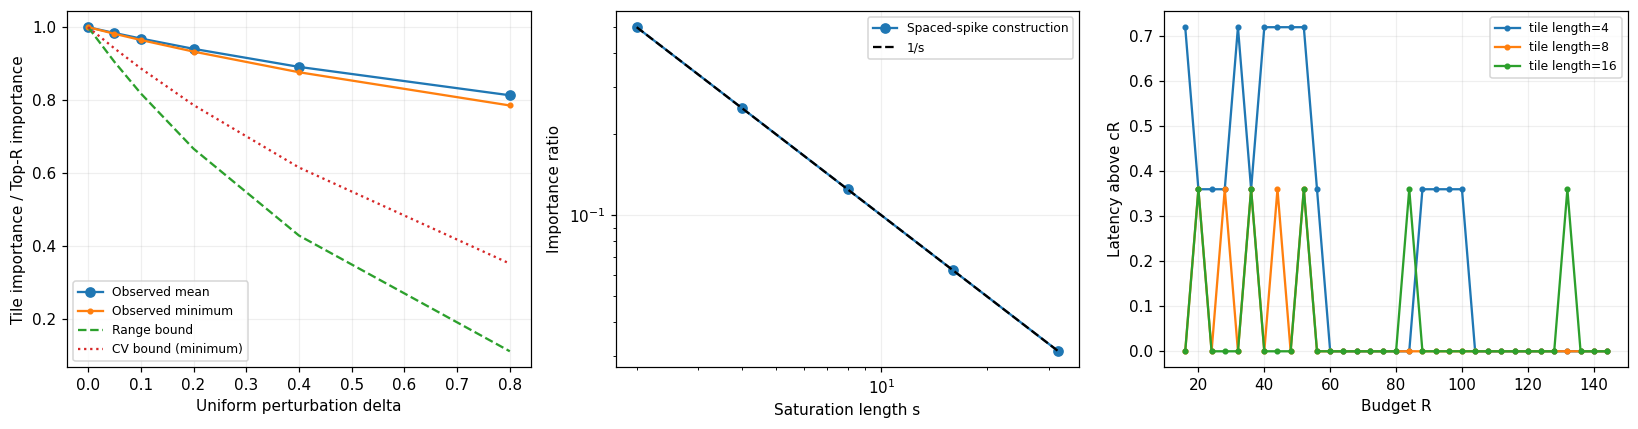

**실행에서 확인한 값**

- **certified_cases**: 72

- **plateau_lower_bound_ms**: 15.36

- **worst_smooth_ratio**: 0.785325895817565

- **worst_spike_ratio**: 0.03125

- **scope**: Latency optimality requires a true plateau and R divisible by s; arbitrary importance has no near-optimal guarantee

In [3]:
v = C.workload(n, SEED, "smooth")
sensitivity = []
for length in [s // 2, s, s * 2]:
    for budget in range(16, 145, 4):
        mask = C.saturation(v, budget, cost, length)
        sensitivity.append(dict(length=length, R=budget, latency=C.latency(mask, cost),
                                excess=C.latency(mask, cost) - .12 * budget,
                                retained=v[mask].sum()/v.sum()))
varied = pd.DataFrame(sensitivity)
varied.to_csv(RUN / "length_sensitivity.csv", index=False)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
summary = frame.groupby("delta").agg(mean=("ratio", "mean"), minimum=("ratio", "min"),
                                    lower=("range_bound", "first"), cv=("cv_bound", "min"))
axes[0].plot(summary.index, summary["mean"], "o-", label="Observed mean")
axes[0].plot(summary.index, summary.minimum, ".-", label="Observed minimum")
axes[0].plot(summary.index, summary.lower, "--", label="Range bound")
axes[0].plot(summary.index, summary.cv, ":", label="CV bound (minimum)")
axes[0].set(xlabel="Uniform perturbation delta", ylabel="Tile importance / Top-R importance")
axes[1].loglog(spike_frame.s, spike_frame.ratio, "o-", label="Spaced-spike construction")
axes[1].loglog(spike_frame.s, spike_frame.bound, "k--", label="1/s")
axes[1].set(xlabel="Saturation length s", ylabel="Importance ratio")
for length, group in varied.groupby("length"):
    axes[2].plot(group.R, group.excess, ".-", label=f"tile length={length}")
axes[2].set(xlabel="Budget R", ylabel="Latency above cR")
for ax in axes:
    ax.legend(fontsize=8)
figure(RUN, "conditional_guarantees")
finish(RUN, certified_cases=len(frame), plateau_lower_bound_ms=.12*r,
       worst_smooth_ratio=float(frame.ratio.min()), worst_spike_ratio=float(spike_frame.ratio.min()),
       scope="Latency optimality requires a true plateau and R divisible by s; arbitrary importance has no near-optimal guarantee")